# Standard Scenario: agentgateway + InferencePool vs plain k8s Service

**Scenario:** Mixed synthetic prompts (~256 token input, ~128 token output).  
**Load:** Constant, 3 stages — 10 → 20 → 30 QPS, 20 s each.  
**Goal:** Measure the baseline EPP overhead (ext_proc gRPC round-trip) under weak routing signal.

```
agentgateway path:  client → agentgateway (Rust proxy) → EPP (ext_proc) → inference-sim pod
baseline path:      client → k8s Service (round-robin) → inference-sim pod
```

**EPP overhead formula:**
```
EPP overhead = latency(agentgateway + InferencePool) − latency(plain k8s Service)
```

In [12]:
import json
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Locate result files ───────────────────────────────────────────────────────
BENCH_DIR = Path("__file__").resolve().parent.parent
RESULTS_DIR = BENCH_DIR / "results"

def latest_run(target: str) -> Path:
    """Return the most recent timestamped run directory that has all stage files."""
    runs = sorted((RESULTS_DIR / target).iterdir(), reverse=True)
    for run in runs:
        if len(list(run.glob("stage_*_lifecycle_metrics.json"))) == 3:
            return run
    raise FileNotFoundError(
        f"No complete run found under {RESULTS_DIR / target}. "
        "Run 'bash benchmarks/scripts/run-benchmark.sh' first."
    )

AGW_DIR  = latest_run("agentgateway")
BASE_DIR = latest_run("baseline")
print(f"agentgateway run : {AGW_DIR.name}")
print(f"baseline run     : {BASE_DIR.name}")

agentgateway run : 20260405T094236Z
baseline run     : 20260405T094236Z


In [13]:
# ── Load per-stage data ───────────────────────────────────────────────────────
QPS_STAGES = [10, 20, 30]
STAGE_LABELS = [f"{q} QPS" for q in QPS_STAGES]

def load_stage(run_dir: Path, stage: int) -> dict:
    path = run_dir / f"stage_{stage}_lifecycle_metrics.json"
    with open(path) as f:
        return json.load(f)

agw_stages  = [load_stage(AGW_DIR,  i) for i in range(3)]
base_stages = [load_stage(BASE_DIR, i) for i in range(3)]

def lat_ms(stage: dict, pct: str) -> float:
    """Request latency in milliseconds for a given percentile (p50/p90/p95/p99)."""
    key = "median" if pct == "p50" else pct
    val = (stage["successes"]["latency"]["request_latency"] or {}).get(key, 0.0)
    return val * 1000

def tpot_us(stage: dict, pct: str) -> float:
    """Normalised time-per-output-token in microseconds."""
    key = "median" if pct == "p50" else pct
    val = (stage["successes"]["latency"]["normalized_time_per_output_token"] or {}).get(key, 0.0)
    return val * 1_000_000

def throughput(stage: dict, metric: str) -> float:
    return stage["successes"]["throughput"].get(metric, 0.0)

# ── Styling ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})
AGW_COLOR  = "#3B82F6"   # blue
BASE_COLOR = "#10B981"   # green
DELTA_POS  = "#EF4444"   # red  (agentgateway slower)
DELTA_NEG  = "#10B981"   # green (agentgateway faster)

print("Data loaded.")

Data loaded.


## 1. Raw Numbers

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'':30} {'10 QPS':>10} {'20 QPS':>10} {'30 QPS':>10}")
print("-" * 62)

rows = [
    ("AGW  latency p50  (ms)",  [lat_ms(s, "p50")  for s in agw_stages]),
    ("AGW  latency p90  (ms)",  [lat_ms(s, "p90")  for s in agw_stages]),
    ("AGW  latency p95  (ms)",  [lat_ms(s, "p95")  for s in agw_stages]),
    ("AGW  latency p99  (ms)",  [lat_ms(s, "p99")  for s in agw_stages]),
    ("-" * 30, None),
    ("Base latency p50  (ms)",  [lat_ms(s, "p50")  for s in base_stages]),
    ("Base latency p90  (ms)",  [lat_ms(s, "p90")  for s in base_stages]),
    ("Base latency p95  (ms)",  [lat_ms(s, "p95")  for s in base_stages]),
    ("Base latency p99  (ms)",  [lat_ms(s, "p99")  for s in base_stages]),
    ("-" * 30, None),
    ("AGW  TPOT p90     (µs)",  [tpot_us(s, "p90") for s in agw_stages]),
    ("Base TPOT p90     (µs)",  [tpot_us(s, "p90") for s in base_stages]),
    ("-" * 30, None),
    ("AGW  output tok/s",        [throughput(s, "output_tokens_per_sec") for s in agw_stages]),
    ("Base output tok/s",        [throughput(s, "output_tokens_per_sec") for s in base_stages]),
    ("AGW  requests/s",          [throughput(s, "requests_per_sec")      for s in agw_stages]),
    ("Base requests/s",          [throughput(s, "requests_per_sec")      for s in base_stages]),
    ("-" * 30, None),
    ("AGW  failures",            [s["failures"]["count"] for s in agw_stages]),
    ("Base failures",            [s["failures"]["count"] for s in base_stages]),
]

for label, vals in rows:
    if vals is None:
        print(label)
    else:
        print(f"{label:30} {vals[0]:>10.2f} {vals[1]:>10.2f} {vals[2]:>10.2f}")

                                   10 QPS     20 QPS     30 QPS
--------------------------------------------------------------
AGW  latency p50  (ms)               4.01       4.04       3.94
AGW  latency p90  (ms)               4.87       4.59       4.57
AGW  latency p95  (ms)               6.79       4.74       4.76
AGW  latency p99  (ms)              10.35       5.08       5.14
------------------------------
Base latency p50  (ms)               1.94       1.83       1.79
Base latency p90  (ms)               2.51       2.25       2.21
Base latency p95  (ms)               4.72       2.36       2.32
Base latency p99  (ms)               6.61       2.45       2.44
------------------------------
AGW  TPOT p90     (µs)              50.67      45.96      44.16
Base TPOT p90     (µs)              25.81      20.60      19.77
------------------------------
AGW  output tok/s                 1309.30    2608.19    3977.33
Base output tok/s                 1294.10    2653.24    3955.90
AGW  request

## 2. E2E Request Latency — Grouped Bar Charts

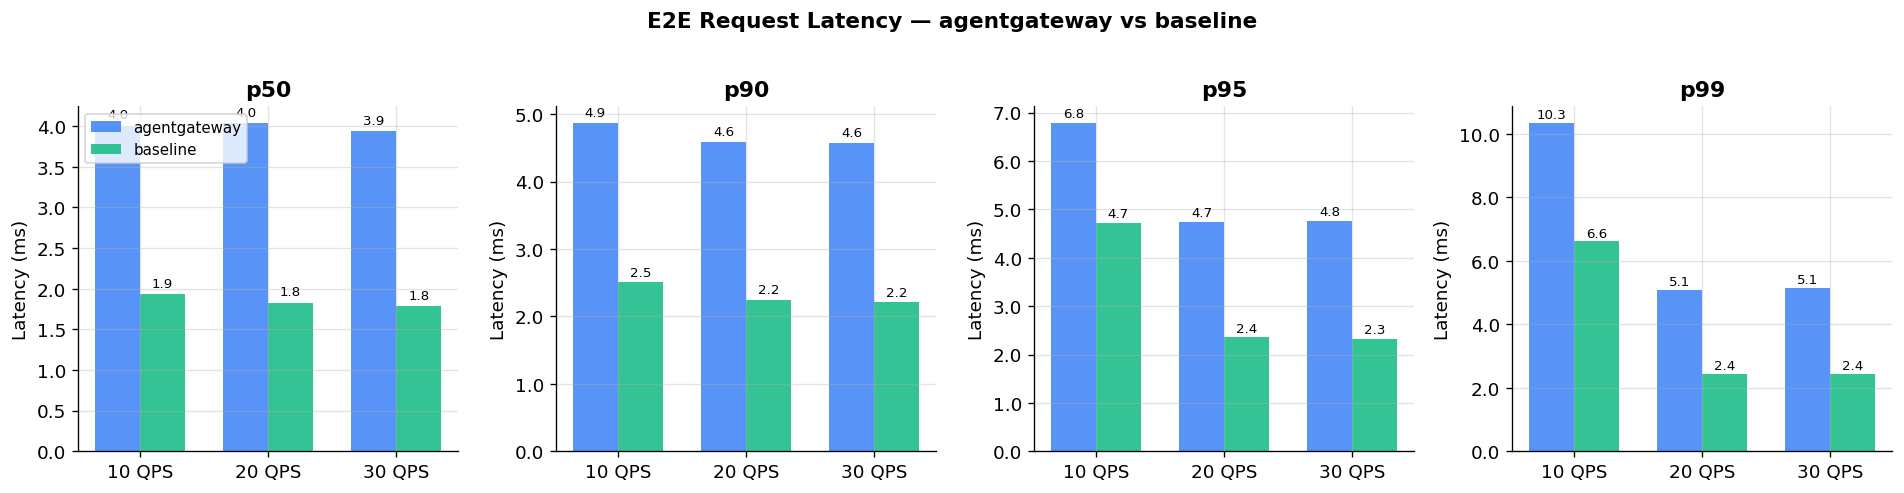

Saved: latency_comparison.png


In [15]:
percentiles = ["p50", "p90", "p95", "p99"]
fig, axes = plt.subplots(1, len(percentiles), figsize=(16, 4), sharey=False)
fig.suptitle("E2E Request Latency — agentgateway vs baseline", fontsize=13, fontweight="bold", y=1.02)

x = np.arange(len(QPS_STAGES))
width = 0.35

for ax, pct in zip(axes, percentiles):
    agw_vals  = [lat_ms(s, pct) for s in agw_stages]
    base_vals = [lat_ms(s, pct) for s in base_stages]

    bars_a = ax.bar(x - width/2, agw_vals,  width, label="agentgateway", color=AGW_COLOR,  alpha=0.85)
    bars_b = ax.bar(x + width/2, base_vals, width, label="baseline",     color=BASE_COLOR, alpha=0.85)

    ax.set_title(pct, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(STAGE_LABELS)
    ax.set_ylabel("Latency (ms)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    # Value labels on top of bars
    for bar in [*bars_a, *bars_b]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f"{h:.1f}",
                ha="center", va="bottom", fontsize=8)

axes[0].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("latency_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: latency_comparison.png")

## 3. Throughput

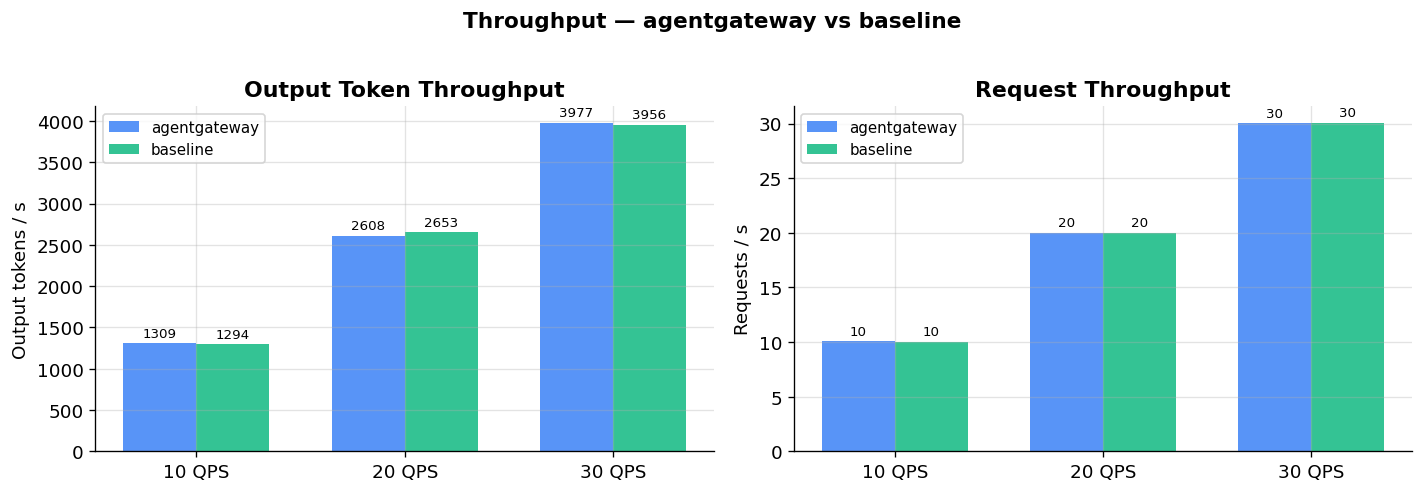

Saved: throughput_comparison.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Throughput — agentgateway vs baseline", fontsize=13, fontweight="bold", y=1.02)

for ax, metric, ylabel, title in [
    (ax1, "output_tokens_per_sec", "Output tokens / s", "Output Token Throughput"),
    (ax2, "requests_per_sec",      "Requests / s",      "Request Throughput"),
]:
    agw_vals  = [throughput(s, metric) for s in agw_stages]
    base_vals = [throughput(s, metric) for s in base_stages]

    bars_a = ax.bar(x - width/2, agw_vals,  width, label="agentgateway", color=AGW_COLOR,  alpha=0.85)
    bars_b = ax.bar(x + width/2, base_vals, width, label="baseline",     color=BASE_COLOR, alpha=0.85)

    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(STAGE_LABELS)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

    for bar in [*bars_a, *bars_b]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(agw_vals+base_vals)*0.01,
                f"{h:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("throughput_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: throughput_comparison.png")

## 4. EPP Overhead — Percentage Delta

Shows `(agentgateway − baseline) / baseline × 100%` per QPS stage.  
**Positive = agentgateway is slower (EPP overhead cost).**  
**Negative = agentgateway is faster (EPP routing benefit).**

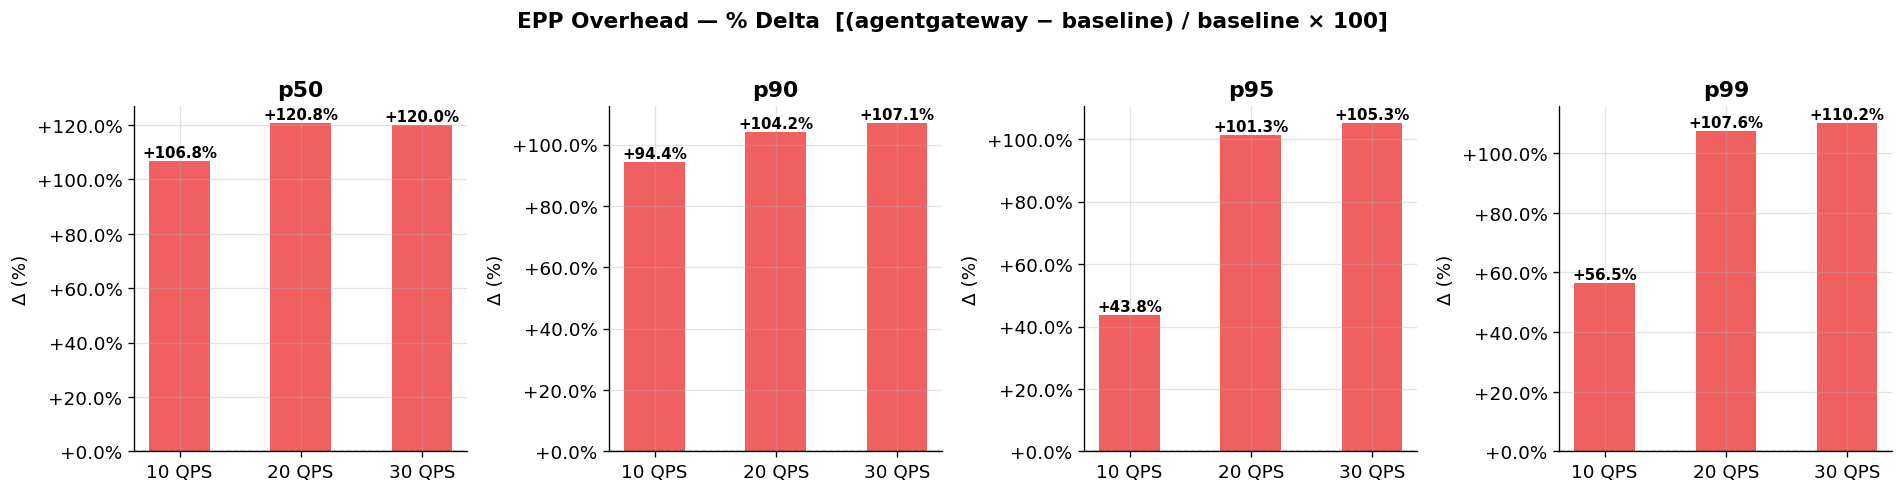

Saved: epp_overhead_delta.png


In [9]:
fig, axes = plt.subplots(1, len(percentiles), figsize=(16, 4), sharey=False)
fig.suptitle("EPP Overhead — % Delta  [(agentgateway − baseline) / baseline × 100]",
             fontsize=13, fontweight="bold", y=1.02)

for ax, pct in zip(axes, percentiles):
    agw_vals  = np.array([lat_ms(s, pct) for s in agw_stages])
    base_vals = np.array([lat_ms(s, pct) for s in base_stages])
    delta_pct = (agw_vals - base_vals) / base_vals * 100

    colors = [DELTA_POS if d > 0 else DELTA_NEG for d in delta_pct]
    bars = ax.bar(x, delta_pct, width=0.5, color=colors, alpha=0.85)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(pct, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(STAGE_LABELS)
    ax.set_ylabel("Δ (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.1f%%"))

    for bar, d in zip(bars, delta_pct):
        offset = 0.3 if d >= 0 else -1.5
        ax.text(bar.get_x() + bar.get_width()/2, d + offset,
                f"{d:+.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("epp_overhead_delta.png", bbox_inches="tight")
plt.show()
print("Saved: epp_overhead_delta.png")

## 5. TPOT — Time Per Output Token

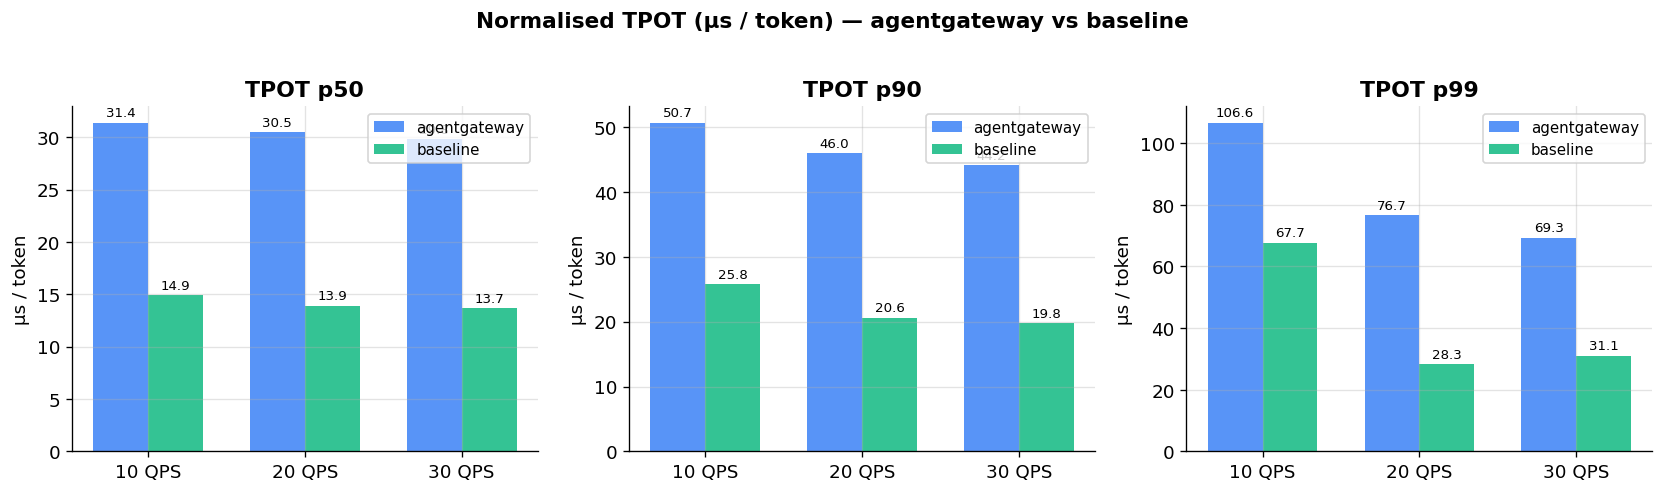

Saved: tpot_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Normalised TPOT (µs / token) — agentgateway vs baseline",
             fontsize=13, fontweight="bold", y=1.02)

for ax, pct in zip(axes, ["p50", "p90", "p99"]):
    agw_vals  = [tpot_us(s, pct) for s in agw_stages]
    base_vals = [tpot_us(s, pct) for s in base_stages]

    bars_a = ax.bar(x - width/2, agw_vals,  width, label="agentgateway", color=AGW_COLOR,  alpha=0.85)
    bars_b = ax.bar(x + width/2, base_vals, width, label="baseline",     color=BASE_COLOR, alpha=0.85)

    ax.set_title(f"TPOT {pct}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(STAGE_LABELS)
    ax.set_ylabel("µs / token")
    ax.legend(fontsize=9)

    for bar in [*bars_a, *bars_b]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(agw_vals+base_vals)*0.01,
                f"{h:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("tpot_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: tpot_comparison.png")

## 6. Sanity Checks

Verify the benchmark ran as intended — actual QPS matches configured QPS, token lengths are in the expected range, and there are no unexpected failures.

In [11]:
print(f"{'Metric':40} {'10 QPS':>10} {'20 QPS':>10} {'30 QPS':>10}")
print("-" * 72)

sanity_rows = [
    ("AGW  achieved QPS",
     [s["load_summary"].get("achieved_rate",
      throughput(s, "requests_per_sec")) for s in agw_stages]),
    ("Base achieved QPS",
     [s["load_summary"].get("achieved_rate",
      throughput(s, "requests_per_sec")) for s in base_stages]),
    ("─" * 40, None),
    ("AGW  mean prompt len (tokens)",
     [(s["successes"]["prompt_len"] or {}).get("mean", 0) for s in agw_stages]),
    ("AGW  mean output len (tokens)",
     [(s["successes"]["output_len"] or {}).get("mean", 0) for s in agw_stages]),
    ("─" * 40, None),
    ("AGW  total requests",
     [s["load_summary"]["count"] for s in agw_stages]),
    ("AGW  successes",
     [s["successes"]["count"] for s in agw_stages]),
    ("AGW  failures",
     [s["failures"]["count"] for s in agw_stages]),
    ("Base failures",
     [s["failures"]["count"] for s in base_stages]),
]

for label, vals in sanity_rows:
    if vals is None:
        print(label)
    else:
        print(f"{label:40} {vals[0]:>10.1f} {vals[1]:>10.1f} {vals[2]:>10.1f}")

total_failures = sum(s["failures"]["count"] for s in agw_stages + base_stages)
print(f"\nTotal failures across all stages and both targets: {total_failures}")
if total_failures == 0:
    print("✓ Clean run — no failures.")
else:
    print("⚠ Failures detected — check the stage JSON files for details.")

Metric                                       10 QPS     20 QPS     30 QPS
------------------------------------------------------------------------
AGW  achieved QPS                              10.1       20.0       30.0
Base achieved QPS                              10.0       20.0       30.1
────────────────────────────────────────
AGW  mean prompt len (tokens)                 253.8      257.3      257.5
AGW  mean output len (tokens)                 130.2      130.4      132.5
────────────────────────────────────────
AGW  total requests                           200.0      400.0      600.0
AGW  successes                                200.0      400.0      600.0
AGW  failures                                   0.0        0.0        0.0
Base failures                                   0.0        0.0        0.0

Total failures across all stages and both targets: 0
✓ Clean run — no failures.


## 7. Interpretation

This Standard scenario is designed as a **floor-cost measurement** under weak routing signal:
- Short mixed prompts → pod queues stay shallow and roughly equal → EPP has no routing advantage
- The delta is therefore a clean measurement of the ext_proc gRPC overhead per request

**Expected result:** agentgateway latency > baseline latency by a small constant margin (~EPP round-trip overhead).  
**If delta ≈ 0:** The ext_proc path is effectively free for this workload.  
**If delta is large:** Investigate EPP scoring latency or body-buffering overhead in the data plane.

Subsequent scenarios (Prefill-Heavy, Decode-Heavy, Prefix-Cache) will show EPP earning back this overhead — and more — when routing signal is strong.